<a href="https://colab.research.google.com/github/vtk251zhdo/Introduction_to_neural_networks/blob/LAB_3/%D0%9B%D0%90%D0%91%D0%9E%D0%A0%D0%90%D0%A2%D0%9E%D0%A0%D0%9D%D0%90_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[Посилання на датасет](https://drive.google.com/drive/folders/1EV-pGw6aVpTIIYIb3RRa6c-6eoUaUHu4)

In [ ]:
#Імпорт бібліотек
from google.colab import drive
import os
import cv2
import imghdr
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt

drive.mount('/content/drive')

data_dir = '/content/drive/MyDrive/dataset_LAB_3'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Перевірка розширень
image_exts = ['jpeg', 'jpg', 'bmp', 'png']

for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try:
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts:
                print(f'Видалення файлу з невірним розширенням: {image_path}')
                os.remove(image_path)
        except Exception as e:
            print(f'Помилка з файлом {image_path}')

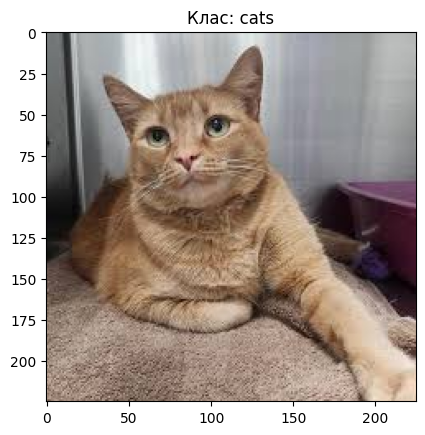

Found 20 files belonging to 2 classes.


In [ ]:
# Зчитування та відображення одної картинки
sample_class = os.listdir(data_dir)[0]
sample_img_name = os.listdir(os.path.join(data_dir, sample_class))[0]
sample_img = cv2.imread(os.path.join(data_dir, sample_class, sample_img_name))
plt.imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
plt.title(f"Клас: {sample_class}")
plt.show()

# Створення датасету
data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(256, 256),
    batch_size=4
)

data_iterator = data.as_numpy_iterator()
batch = data_iterator.next()

In [ ]:
# Нормалізація
data = data.map(lambda x, y: (x / 255, y))

# Розділення даних
train_size = int(len(data) * 0.7)
val_size = int(len(data) * 0.2)
test_size = int(len(data) * 0.1)

train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

model = Sequential([
    Input(shape=(256, 256, 3)),
    Conv2D(16, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(16, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Перевірка перед тренуванням
if len(data) > 2:
    train_size = int(len(data) * 0.7)
    val_size = int(len(data) * 0.2)

    train = data.take(train_size)
    val = data.skip(train_size).take(val_size)

    # Тренування
    history = model.fit(train, epochs=20, validation_data=val)
else:
    print("Помилка")

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 543ms/step - accuracy: 0.6667 - loss: 1.2426 - val_accuracy: 0.2500 - val_loss: 0.7920
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step - accuracy: 0.5000 - loss: 0.7259 - val_accuracy: 0.2500 - val_loss: 0.7745
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 381ms/step - accuracy: 0.6667 - loss: 0.6439 - val_accuracy: 0.5000 - val_loss: 0.6763
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 301ms/step - accuracy: 0.5833 - loss: 0.6863 - val_accuracy: 0.5000 - val_loss: 0.6665
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 300ms/step - accuracy: 0.5833 - loss: 0.6474 - val_accuracy: 0.2500 - val_loss: 0.7527
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 301ms/step - accuracy: 0.5833 - loss: 0.6530 - val_accuracy: 0.7500 - val_loss: 0.5237
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 302ms/step - accuracy: 0.5833 - loss: 0.6407 - val_accuracy: 1.0000 - val_loss: 0.6117
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 302ms/step - accuracy: 0.8333 - loss: 0.5848 - val_accuracy: 0.7500 - val_loss:

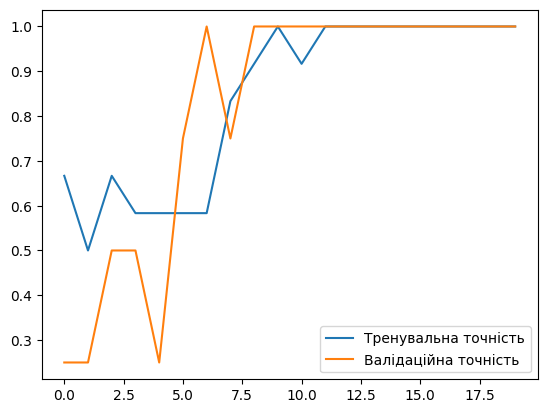

Precision: 0.00
Recall: 0.00
Accuracy: 0.00


In [ ]:
# Відображення результатів
plt.plot(history.history['accuracy'], label='Тренувальна точність')
plt.plot(history.history['val_accuracy'], label='Валідаційна точність')


plt.legend()
plt.show()

# Тестування на відкладених даних
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

pre = Precision()
re = Recall()
acc = BinaryAccuracy()

for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

print(f'Precision: {pre.result().numpy():.2f}')
print(f'Recall: {re.result().numpy():.2f}')
print(f'Accuracy: {acc.result().numpy():.2f}')